# Randomszám generátorok

**Kérdések**:
- Hogyan generáljunk random számot? ([Légköri zajokból](https://www.random.org/))
- Mennyire könnyű ezeket implementálni?
- Mennyire hatékonyak?
- "Mennyire" random egy random szám?
![](./dilbert.jpg)

A matematikai algoritmusoknal elobb\-utobb bekovetkeznek az ismetlodesek.


### (python) Generátor kifejezések, generátor függvények

Részletes használati utasítás [RealPython](https://realpython.com/introduction-to-python-generators/)-on

In [1]:
def inf_seq(): # vegtelen sorozat
    num = 0
    while True:
        yield num
        num += 1

In [2]:
seq = inf_seq()

In [3]:
next(seq) # get element from generator

0

In [4]:
next(seq)

1

## Linear Congruential Generators

Legyen $m \geq 2$, $1 \leq a,b \leq m - 1$ egész számok. Ekkor az $$x_n = ax_{n-1} + b \mod{m}$$ összefüggés az $x_1,x_2,\dots$ sorozatot generálja és $x_0$-t seed-nek nevezzük.

Seed = a kezdo elem

Linearisan szamoljuk a kovetkezo elemet az elozobol


In [5]:
def lcg(a, b, m, seed): # generator fv
    x = seed
    while True:
        
        x = (a*x + b) % m
        
        yield x

**Példa**: Legyen $a=3, b=5, x_0=0, m=31$

In [6]:
gen = lcg(3, 5, 31, 0)

print([next(gen) for _ in range(40)]) # 30 szamonkenti ismetlodes

[5, 20, 3, 14, 16, 22, 9, 1, 8, 29, 30, 2, 11, 7, 26, 21, 6, 23, 12, 10, 4, 17, 25, 18, 28, 27, 24, 15, 19, 0, 5, 20, 3, 14, 16, 22, 9, 1, 8, 29]


**Példa**: Legyen $a=65539, b=0, x_0=1, m=2^{31}$. 

In [7]:
gen = lcg(65539, 0, 2 ** 31, 1)
print([next(gen) for _ in range(40)])

[65539, 393225, 1769499, 7077969, 26542323, 95552217, 334432395, 1146624417, 1722371299, 14608041, 1766175739, 1875647473, 1800754131, 366148473, 1022489195, 692115265, 1392739779, 2127401289, 229749723, 1559239569, 845238963, 1775695897, 899541067, 153401569, 1414474403, 663781353, 1989836731, 1670020913, 701529491, 2063890617, 1774610987, 662584961, 888912771, 1517695625, 1105958811, 1566426833, 1592415347, 1899101529, 1357838347, 1792534561]


In [8]:
import matplotlib.pyplot as plt

def plot_2d_spectral_test(seq):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.scatter(seq[:-1], seq[1:], marker='o')
    return fig, ax

def plot_3d_spectral_test(seq, elev, azim):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(seq[:-2], seq[1:-1], seq[2:], marker='o')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.view_init(elev=elev, azim=azim)
    return fig, ax

Spectral test: az egymas koveto szamok a generatorban az x,y koordinatak.

Ha nincs vizualis minta, akkor jo


(<Figure size 1000x1000 with 1 Axes>, <AxesSubplot: xlabel='x', ylabel='y'>)

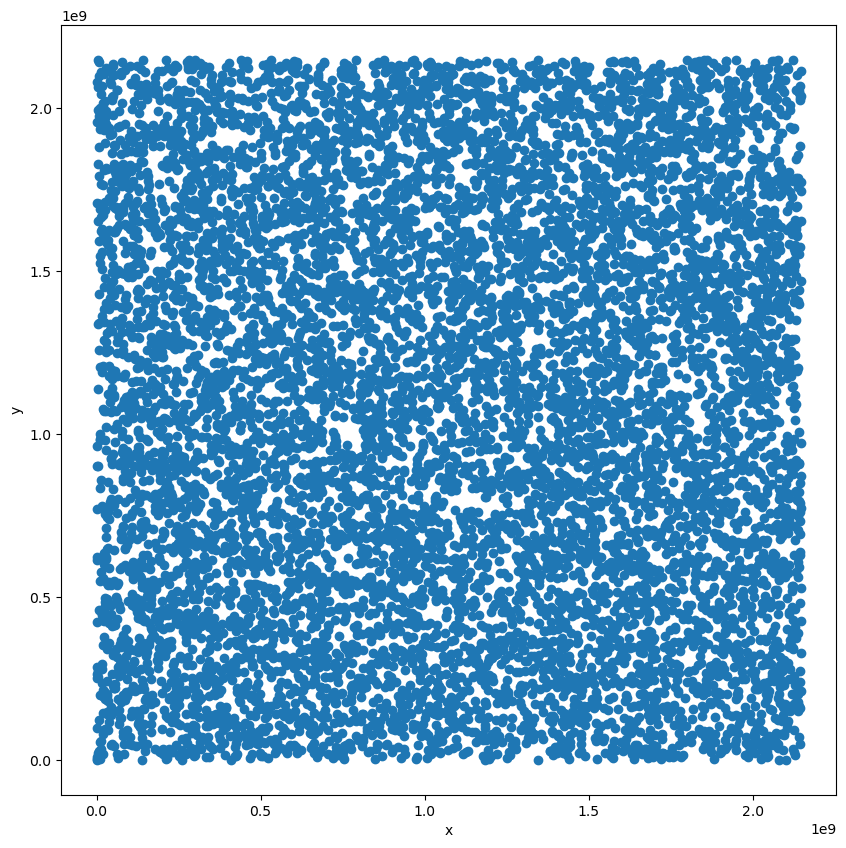

In [9]:
randu = lcg(65539, 0, 2 ** 31, 1)
seq = [next(randu) for _ in range(10000)]
plot_2d_spectral_test(seq)

(<Figure size 1000x1000 with 1 Axes>,
 <Axes3DSubplot: xlabel='x', ylabel='y', zlabel='z'>)

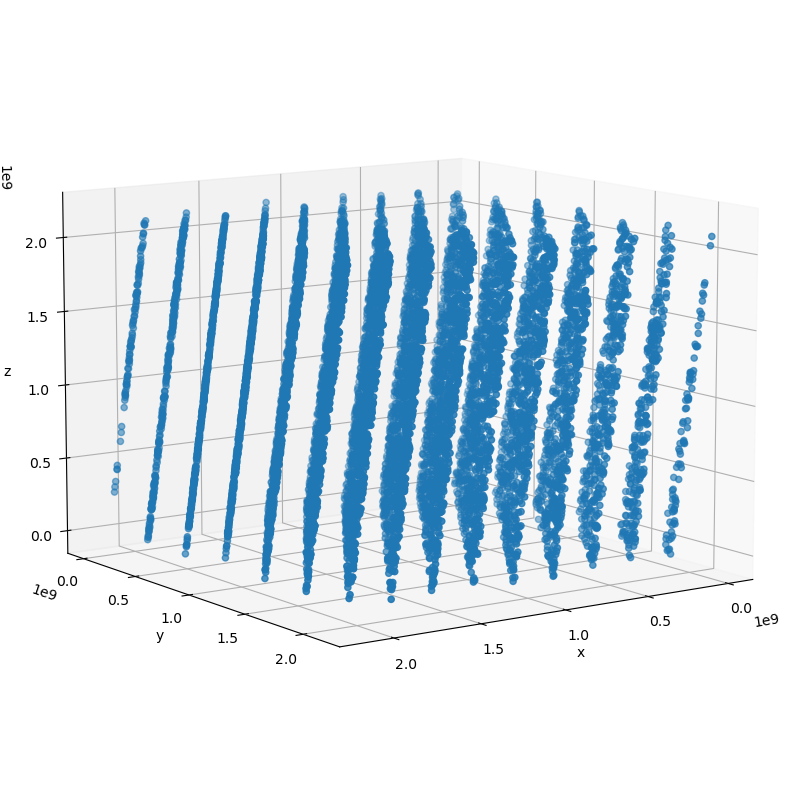

In [10]:
plot_3d_spectral_test(seq, 10, 55)

Mikor lesz egy LCG generátor "jó" generátor (azaz mikor lesz a periódusának hossza maximális)?
- $b$ és $m$ relatív prímek
- minden $p$ prímszámra, ami osztja $m$-et, $a - 1$ a $p$ prímszám többszöröse
- $a - 1$ többszöröse $4$-nek, ha $m$ többszöröse $4$-nek

Elméleti [cikk](https://dl.acm.org/doi/10.1145/63039.63042)

Ezek a paraméterek mind jók lesznek:
1. Legyen $a=65539, b=1, x_0=0, m=2^{31}$.
2. $a=31, b=13, x_0 = 7, m=60$
3. Legyen $a=5, b=5, x_0=3, m=8$

További LCG-típusú generátorok:

- $x_n = (ax_{n-1}^2 + bx_{n-1} + c) \mod{m}$
- $x_n = (ax_{n-1}^3 + bx_{n-1}^2 + cx_{n-1} + d) \mod{m}$

### **[NEM BIZTONSÁGOSAK](https://www.cs.umd.edu/~gasarch/COURSES/456/F18/notes/crackrand.pdf) AZ LCG-TÍPUSÚ GENERÁTOROK!**

De kombinálhatók: nem biztonságosabb, de hosszabb periódus.

**Példa**: Legyen a seed $x_0 = 2134$, $m = 8397, a = 4381, b = 7364$, azaz az LCG generátorunk: $$x_{n+1} = 4381x_n + 7364 \mod{8397}$$

In [11]:
from string import ascii_lowercase
import random

def gen_key(rng, length):
    k = []
    for _ in range(length // 2):
        i = str(next(rng)).zfill(4)
        k.append(i[:2])
        k.append(i[2:])
    return k
    # return [str(next(rng)).zfill(4) for _ in range(length)]

def encode_pt(pt):
    return [str(ascii_lowercase.find(i)).zfill(2) for i in pt]

def encrypt_pt(key, plaintext):
    ct = []
    for k, c in zip(key, plaintext):
        a = (int(k[0]) + int(c[0])) % 10
        b = (int(k[1]) + int(c[1])) % 10
        ct.append(f'{a}{b}')
    return ct

def decrypt_ct(key, ciphertext):
    pt = []
    for k, c in zip(key, ciphertext):
        a = (int(c[0]) - int(k[0])) % 10
        b = (int(c[1]) - int(k[1])) % 10
        pt.append(f'{a}{b}')
    return pt

rng = lcg(4381, 7364, 8397, 2134)
plaintext = encode_pt('lcgrandomnumbergeneratorsaregenerallynotsecure')
secret_key = gen_key(rng, len(plaintext))
ciphertext = encrypt_pt(secret_key, plaintext)
encode_pt(plaintext) == decrypt_ct(secret_key, ciphertext)

print(f"PT : {'  '.join(i for i in 'lcgrandomnumbergeneratorsaregenerallynotsecure')}")
print(f"PT : {' '.join(i for i in plaintext)}")
print(f"KEY: {' '.join(i for i in secret_key)}")
print('-' * 145)
print(f"CT : {' '.join(i for i in ciphertext)}")

PT : l  c  g  r  a  n  d  o  m  n  u  m  b  e  r  g  e  n  e  r  a  t  o  r  s  a  r  e  g  e  n  e  r  a  l  l  y  n  o  t  s  e  c  u  r  e
PT : 11 02 06 17 00 13 03 14 12 13 20 12 01 04 17 06 04 13 04 17 00 19 14 17 18 00 17 04 06 04 13 04 17 00 11 11 24 13 14 19 18 04 02 20 17 04
KEY: 21 60 69 05 37 78 82 95 55 43 71 23 15 78 14 54 40 15 53 64 38 45 79 27 55 59 16 46 54 67 16 50 61 97 05 23 62 46 52 67 71 35 37 68 64 70
-------------------------------------------------------------------------------------------------------------------------------------------------
CT : 32 62 65 12 37 81 85 09 67 56 91 35 16 72 21 50 44 28 57 71 38 54 83 34 63 59 23 40 50 61 29 54 78 97 16 34 86 59 66 76 89 39 39 88 71 74


Egy támadó megszerezte a titkosított üzenetet. Tegyük fel, hogy a támadó tudja, hogy a generátor által visszaadott számok legfeljebb 4 számjegy nagyságúak. A támadó azt gyanítja, hogy a `generally` szó szerepel az eredeti üzenetben. A cél a generátor reprodukálása. 

In [28]:
possible_key = []

for c, p in zip(ciphertext[-9:], encode_pt('generally')):
    a = (int(c[0]) - int(p[0])) % 10
    b = (int(c[1]) - int(p[1])) % 10
    possible_key.append(f'{a}{b}')
    
print(ciphertext[-9:])
print(encode_pt('generally'))
print(possible_key) # random szam generator ket eleme - kulcs becsles a parokbol -> linearis egyenlet rendszer amibol megkapjuk a,b,mod valtozokat az algoritmusnak

['59', '66', '76', '89', '39', '39', '88', '71', '74']
['06', '04', '13', '04', '17', '00', '11', '11', '24']
['53', '62', '63', '85', '22', '39', '77', '60', '50']


3 egyenlet felirhato:

4654 === 5916a\+b\(mod m\) \(1\)

6716=== 4654a\+b\(mod m\) \(2\)

5061=== 6716a\+b\(mod m\) \(3\)

Lepesek: \(2\)\-\(1\) es \(3\)\-\(1\) \-&gt; eltunnek a b\-k majd kozos a\-ra hozas es osszeadas

Kongurenca: a === b \(mod m\) \-&gt; m | \(a \- b\)



In [15]:
divisors(2163234)
divisors(2804598)

[1,
 2,
 3,
 6,
 9,
 18,
 27,
 54,
 167,
 311,
 334,
 501,
 622,
 933,
 1002,
 1503,
 1866,
 2799,
 3006,
 4509,
 5598,
 8397,
 9018,
 16794,
 51937,
 103874,
 155811,
 311622,
 467433,
 934866,
 1402299,
 2804598]

In [17]:
# inverse_mod(800, 8102)
inverse_mod(4, 8397)

6298

# Folyam titkosítók és randomszám generátorok

![](./stream_cipher.png)



## Linear Feedback Shift Registers (LFSR)

Néhány fogalom:
- Minden LFSR $n$ darab regiszterből áll: $s_{n-1},\dots,s_0$
- A regiszterek mellett $n$ darab *feedback együttható* is található: $c_{n-1},\dots,c_0$
- Az LFSR *foka* a regiszterek száma, $n$
- Minden regiszter egy bitet tárol
- Az állapot frissítése: a regiszterek tartalmát egy lépéssel jobbra toljuk, a bal széélső regiszterét pedig a feedback együtthatók alapján számoljuk
- Az LFSR egy állapota a regiszterek aktuális tartalma, formálisan: legyen az állapot $t$ időben $s^{(t)}_{n-1}, \dots, s^{(t)}_0$. A következő $s^{(t+1)}_{n-1},\dots,s^{(t+1)}_0$ állapototaz alábbiak szerint számoljuk:
\begin{align*}
s^{(t+1)}_i &:= s^{(t)}_{i+1} \\
s^{(t+1)}_{n-1} &:= \bigoplus^{n-1}_{i=0} c_i s^{(t)}_{i}
\end{align*}
- Az LFSR által generált bit a jobb szélső regiszter kimenete lesz.

![](./lfsr.png)

In [63]:
from operator import xor
from functools import reduce

seed_ = [0, 1, 1, 1]
coeff_ = [0, 1, 0, 1] #feedbacke egyutthato

def lfsr(seed, coeff, f=xor):
    current = seed
    
    while True:
        
        yield current[-1]
        
        next = reduce(f, map(lambda x: current[x], list(filter(lambda x: coeff[x] == 1, list(range(len(coeff)))))))
        
        current = [next] + current[0:len(current)-1]

In [67]:
gen = lfsr(seed_, coeff_)

print([next(gen) for _ in range(40)])

[1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0]


In [69]:
from operator import and_

gen2 = lfsr(seed_, coeff_, f=lambda x, y: (1 + and_(x, y) + xor(x, y)) % 2)

print([next(gen) for _ in range(40)])

[1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1]


Kérdések:

- Mi lehet egy LFSR periódusa? \(\(2^n\)\-1\)
- Van olyan állapot, ami fixpontja lesz az LFSR\-nek? \(Van: pl XOR eseten a 0000\)
- Mi határozhatja meg az LFSR periódusának hosszát? \(A regiszterek szama es a feedback kapcsolatok\)



**Definíció** (Felbonthatatlan polinom):  

### LFSR törése

Gond: előrejelezhető a következő bit $\rightarrow$ *reconstruction attack*
- $\leq 2n$ megfigyelt bitből visszaállítható az LFSR állapota bármely későbbi időpontban

**Feladat**: Adott az alábbi `seq`, egy LFSR által generált bitsorozat. Az LFSR foka ismeretlen. Határozzuk meg a feedback együtthatókat!

**Megoldás**: Minden lépésben egy lineáris egyenletrendszert fogunk készíteni, majd annak a megoldása alapján ellenőrizzük, hogy az így kapott együtthatókkal kiszámolható-e a sorozat összes többi eleme.
- Legyen $n=2$ ($n=1$-re konstans sorozatot kapnánk, így azt kihagyjuk). A lineáris egyenletrendszer:
\begin{align*}
c_0 \cdot 0 \oplus c_1 \cdot 1 &= 1 \\
c_0 \cdot 1 \oplus c_1 \cdot 1 &= 0 
\end{align*}
Mátrix alakban:
\begin{equation*}
\begin{pmatrix}
0 & 1 \\
1 & 1 
\end{pmatrix}
\begin{pmatrix}
c_0 \\
c_1
\end{pmatrix} = 
\begin{pmatrix}
1 \\
0
\end{pmatrix}
\end{equation*}
A megoldás: $c_0 = 1, c_1 = 1$, de ez nem jó, mert $x_4 \oplus x_5 = 0 \oplus 1 \ne 0$
- Legyen $n = 3$:
\begin{equation*}
\begin{pmatrix}
0 & 1 & 1 \\
1 & 1 & 0 \\
1 & 0 & 1
\end{pmatrix}
\begin{pmatrix}
c_0 \\ c_1 \\ c_2
\end{pmatrix} =
\begin{pmatrix}
0 \\ 1 \\ 0
\end{pmatrix}
\end{equation*}
Mivel a mátrix determinánsa $0 \mod{2}$, a fenti egyenletrendszernek nincs megoldása.
- Legyen $n = 4$:
\begin{equation*}
\begin{pmatrix}
0 & 1 & 1 & 0 \\
1 & 1 & 0 & 1 \\
1 & 0 & 1 & 0 \\
0 & 1 & 0 & 1
\end{pmatrix}
\begin{pmatrix}
c_0 \\ c_1 \\ c_2 \\ c_3
\end{pmatrix} =
\begin{pmatrix}
1 \\ 0 \\ 1 \\ 1
\end{pmatrix}
\end{equation*}
A megoldás $c_0 = 1, c_1 = 1, c_2 = 0, c_3 = 0$, ami már a jó sorozatot fogja legyártani.

Általános esetben:
\begin{equation*}
\begin{pmatrix}
x_1 & x_2 & \cdots & x_n \\
x_2 & x_3 & \cdots & x_{n+1} \\
\vdots & \vdots & \ddots & \vdots \\
x_n & x_{n+1} & \cdots & x_{2n-1} 
\end{pmatrix}
\begin{pmatrix}
c_0 \\ c_1 \\ \vdots \\ c_{n-1}
\end{pmatrix} =
\begin{pmatrix}
x_{n+1} \\ x_{n+2} \\ \vdots \\ x_{2n}
\end{pmatrix}
\end{equation*}

In [70]:
seq = [0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1]

In [71]:
def break_coeffs(s):
    
    for n in range(len(s)):
        
        # solve linear eqs
        
        res = []
        gen = lfsr(s[:n], res)
        
        if s == [next(gen) for _ in range(len(s))]:
            return n
        
    return 0

In [72]:
break_coeffs(seq)

IndexError: list index out of range

Hogyan lehet nehezíteni a támadást? **Nonlinerar-feedback shift register (FSR)**: 
Ugyanaz, mint eddig, de az új értéket számoló függvény nemlineáris.

### Geffe generátor

Három LFSR-t, A, B, és C tartalmaz, amik rendje az a,b,c kimenetet adják. A titkos kulcsot az $k = (a \wedge \neg b) \oplus (b \wedge c)$ adja meg. A periódus az egyes LFSR periódusok legkisebb közös többszöröse. 

![](./geffe.png)

Papíron jól néz ki, de [több](https://aip.scitation.org/doi/pdf/10.1063/1.5132456) [törés](https://ieeexplore.ieee.org/document/1055626) [alkalmazható](https://ieeexplore.ieee.org/document/67207)

További LFSR-re épülő generátorok:
- Jennings generátor
- Beth-Piper Stop-and-Go generátor
- Alternating Stop-and-Go generátor
- Threshold generátor
- Self-decimated generátor
- Multispeed Inner-product generátor
- Summation generátor
- (Self-)Shrinking generátor
- Feedback with Carry Shift Register
- ...

## Kriptográfiailag biztonságos generátorok

Jellemzően valamilyen nehéz problémára építenek.

### Blum-Blum-Shub

Lenore Blum, Manuel Blum és Michael Shub (1986)

Legyenek $p,q$ (nagy) prímszámok úgy, hogy $p\,\text{mod}\,4 = q\,\text{mod}\,4 = 3$ és $M=pq$. Legyen a seed $x_0$ relatív prím $M$-mel. Legyen $x_n = x_{n-1}^2 \mod{M}$ és a generált random bit $x_n$ utolsó bitje.

Érdekesség: bármely $x_i$ értéket közvetlenül ki lehet számolni: $x_i = \left( x_{0}^{2^i\mod{\lambda(M)}} \right) \mod{M}$, ahol $\lambda(M) = \text{lcm}(p-1, q-1)$

### Blum-Micali generátor

Legyen $p$ egy prímszám és $q$ egy páratlan prímszám. Legyen $x_0$ a seed. Legyen $x_n = p^{x_{n-1}} \mod{q}$ és a generált random bit legyen $1$, ha $x_{n-1} < (q-1)/2$, egyébként $0$.

**Állítás**: Ha $q$ elég nagy, akkor a fenti összefüggést nehéz kiszámolni, és a generátor biztonságos. (Lásd még: diszkrét logaritmus probléma, később)

### RSA generátor

Legyenek $p,q$ nagy prímszámok. Legyen $N=pq$ és $e$ úgy, hogy relatív prím legyen $(p-1)(q-1)$ szorzattal. Legyen $x_0 < N$ a seed. A generátor: $x_{n} = x^e_{n-1} \mod{N}$, és a random bit az $x_n$ least significant bit-je.

**Állítás**: Ha $p,q$ elég nagyok, akkor a generátor biztonságos. (Lásd még: RSA, később)

## Statisztikai tesztek

- NIST: https://csrc.nist.gov/Projects/Random-Bit-Generation/Documentation-and-Software
- Diehard: https://ani.stat.fsu.edu/diehard/
- TestU1

# Feladatok

1. Implementáljuk a fenti, kriptográfiailag biztonságos generátorokat! Opcionálisan alkalmazzunk rájuk statisztikai tesztet.
2. Implementáljuk a következő, LCG típusú randomszám-generátorokat és határozzuk meg a periódusaik hosszát és az első öt elemét a sorozatoknak! Opcionálisan nézzük meg rájuk a 2D és 3D spectral test-et is (ehhez használható a gyakorlaton látott kód)!
    1. Az ACORN generátor a következőképp működik:
       - Válasszunk egy $k \geq 1$ egész számot
       - Válasszunk egy $M$ és egy $Y_0^{(0)}$ seed értéket, amikre $0 < Y_0^{(0)} < M$ teljesül és $Y_0^{(0)}$ és $M$ relatív prímek
       - Válasszunk $k$ darab tetszőleges egész számot, $Y_0^{(1)}, Y_0^{(2)},\dots,Y_0^{(k)}$, amikre teljesül, hogy $0 \leq Y_0^{(j)} < M$, minden $j=1,2,\dots,k$ értékre
        - Számoljuk ki a sorozat elemeit: $$Y_{i}^{(j)} = \left( Y_{i}^{(j-1)} + Y_{i-1}^{(j)} \right) \mod{M},$$ minden $j = 1,2,\dots,k$ számra
    2. L’Ecuyer MRG32k3a generátor:
       \begin{align*}
           x_i &= (a_{11}x_{i-1} + a_{12}x_{i-2} + a_{13}x_{i-3}) \mod{m_1} \\
           y_i &= (a_{21}y_{i-1} + a_{22}y_{i-2} + a_{23}y_{i-3}) \mod{m_2} \\
           z_i &= (x_i - y_i) \mod{m_1} \\
           u_i &= (z_i + 1) / m_1,
       \end{align*}
       ahol $a_11 = 0$, $a_{12} = 1403580$, $a_{13} = -810728$, $m_1 = 2^{32} - 209$, $a_{21} = 527612$, $a_{22} = 0$, $a_{23} = -1370589$, $m_2 = 2^{32} - 22853$ és $u_i$ a sorozat egy eleme a $(0,1]$ intervallumban.
3. Implementáljuk az exclusive OR generátort (XORG)! A seed 127 bit hosszú, az i-edik generált bitet az $x_i = x_{i-1} \oplus x_{i-127}$ adja meg
4. Nézzünk utána, hogyan működnek a (Self-)Shrinking és a Feedback with Carry Shift Register generátorok, majd adjuk meg egy implementációját is!